<a href="https://colab.research.google.com/github/12370043/keiichiro/blob/main/260424_%E5%AE%A4%E5%86%85%E6%B0%97%E6%B5%81.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

TensorFlow: 2.19.0
GPU: []
entrance  : 2026-04-24 15:51:22 → 2026-04-24 15:53:36 (125行)
center    : 2026-04-24 15:48:14 → 2026-04-24 15:50:19 (116行)
notentrance: 2026-04-24 15:55:38 → 2026-04-24 15:57:39 (114行)


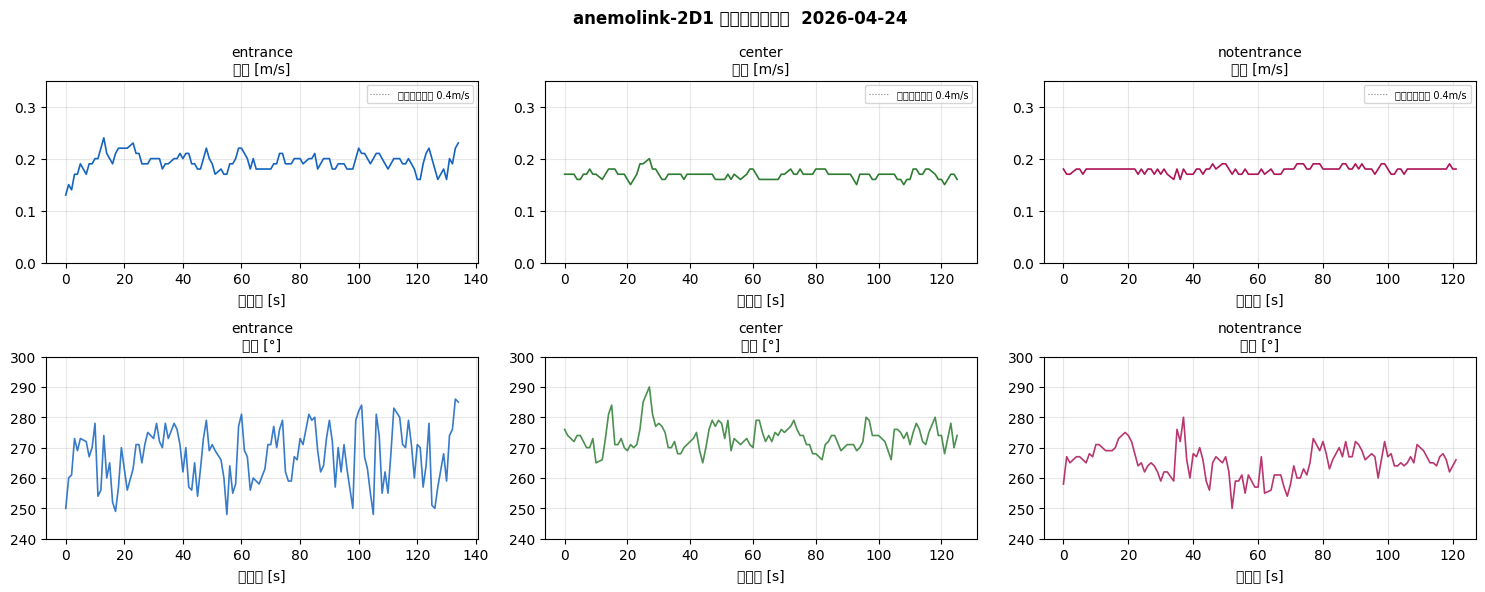

使用サンプル数（各地点）: 122 ステップ
学習: 89  テスト: 23
入力形状: (89, 8, 3)  出力形状: (89, 6)


Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_entrance      │ (None, 8, 3)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_center        │ (None, 8, 3)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_entrance       │ (None, 16)        │      1,280 │ input_entrance[0… │
│ (LSTM)              │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_center (LSTM)  │ (None, 16)        │      1,280 │ input_center[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ merge (Concatenate) │ (None, 32)        │          0 │ lstm_entrance[0]… │
│                     │                   │            │ lstm_center[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 16)        │        528 │ merge[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 16)        │          0 │ dense_3[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ output (Dense)      │ (None, 6)         │        102 │ dropout_2[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 3,190 (12.46 KB)

 Trainable params: 3,190 (12.46 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/300
17/17 ━━━━━━━━━━━━━━━━━━━━ 5s 40ms/step - loss: 0.1505 - mae: 0.3032 - val_loss: 0.1458 - val_mae: 0.2778 - learning_rate: 5.0000e-04
Epoch 2/300
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.1265 - mae: 0.2718 - val_loss: 0.1141 - val_mae: 0.2514 - learning_rate: 5.0000e-04
Epoch 3/300
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0974 - mae: 0.2381 - val_loss: 0.0906 - val_mae: 0.2288 - learning_rate: 5.0000e-04
Epoch 4/300
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0842 - mae: 0.2221 - val_loss: 0.0710 - val_mae: 0.2024 - learning_rate: 5.0000e-04
Epoch 5/300
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0845 - mae: 0.2264 - val_loss: 0.0592 - val_mae: 0.1829 - learning_rate: 5.0000e-04
Epoch 6/300
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0770 - mae: 0.2133 - val_loss: 0.0517 - val_mae: 0.1705 - learning_rate: 5.0000e-04
Epoch 7/300
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0757 - mae: 0.2104 - val_loss: 0.0481 - val_mae: 0.1627 - lear

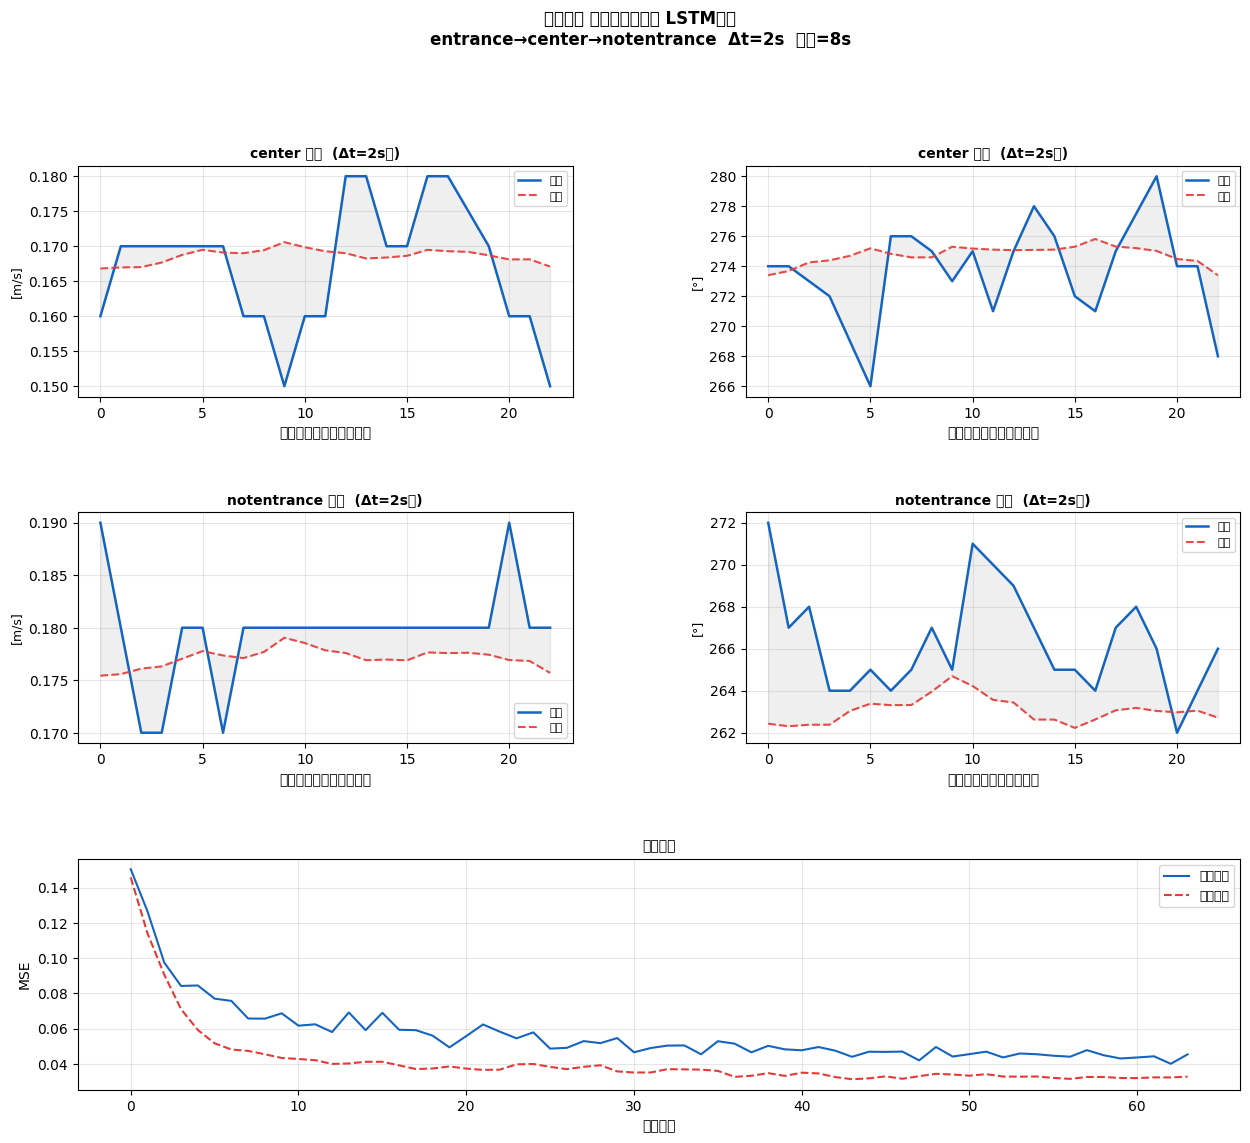

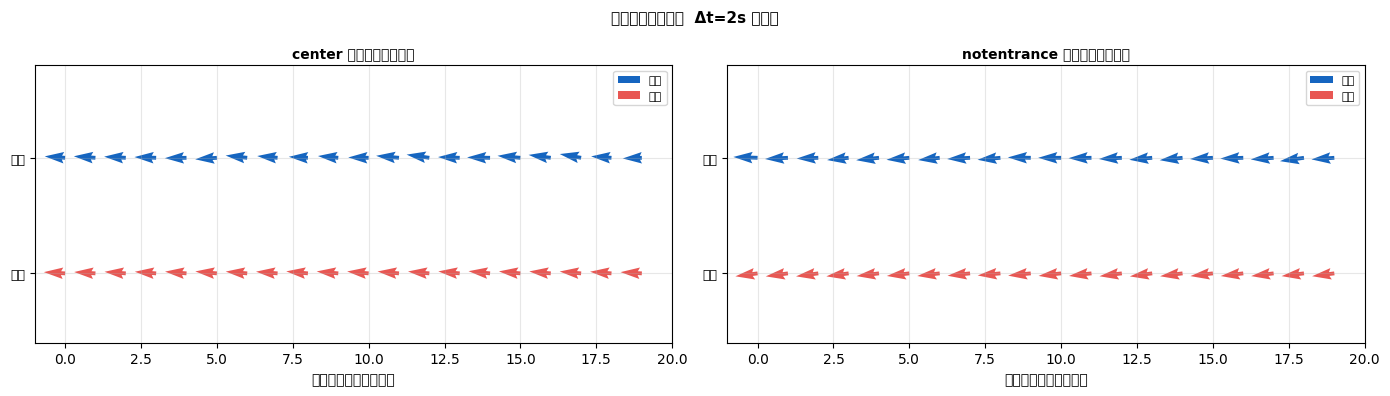

In [3]:
# ============================================================
# セル1: ライブラリ
# ============================================================
!pip install numpy pandas matplotlib scikit-learn tensorflow -q

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input, LSTM, Dense, Concatenate, Dropout, LayerNormalization
)
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
import warnings
warnings.filterwarnings('ignore')

print("TensorFlow:", tf.__version__)
print("GPU:", tf.config.list_physical_devices('GPU'))


PATH_ENTRANCE = '/content/20260424_entrance_120s.csv'
PATH_CENTER   = '/content/20260424_center_120s.csv'
PATH_NOTENT   = '/content/20260424_notentrance_120s.csv'

# ------ 読み込み ------
def load_sensor(path, label):
    df = pd.read_csv(path)
    # タイムスタンプ列を生成（秒精度）
    df['ts'] = (pd.to_datetime(
        df['#year'].astype(str) + '-' +
        df['month'].astype(str).str.zfill(2) + '-' +
        df['day'].astype(str).str.zfill(2) + ' ' +
        df['hour'].astype(str).str.zfill(2) + ':' +
        df['minute'].astype(str).str.zfill(2) + ':' +
        df['second'].astype(str).str.zfill(2)
    ))
    df = df[['ts', 'wind_velocity', 'wind_direction']].copy()
    df.columns = ['ts', f'speed_{label}', f'dir_{label}']
    df = df.drop_duplicates('ts').sort_values('ts').reset_index(drop=True)
    return df

df_ent  = load_sensor(PATH_ENTRANCE, 'ent')
df_mid  = load_sensor(PATH_CENTER,   'mid')
df_far  = load_sensor(PATH_NOTENT,   'far')

print("entrance  :", df_ent['ts'].iloc[0], "→", df_ent['ts'].iloc[-1],
      f"({len(df_ent)}行)")
print("center    :", df_mid['ts'].iloc[0], "→", df_mid['ts'].iloc[-1],
      f"({len(df_mid)}行)")
print("notentrance:", df_far['ts'].iloc[0], "→", df_far['ts'].iloc[-1],
      f"({len(df_far)}行)")

# ------ 欠損秒の補間（線形）------
def fill_gaps(df, ts_col, freq='1s'):
    """1秒グリッドに揃えて線形補間"""
    df = df.set_index(ts_col)
    full_idx = pd.date_range(df.index.min(), df.index.max(), freq=freq)
    df = df.reindex(full_idx).interpolate('linear').reset_index()
    df.rename(columns={'index': ts_col}, inplace=True)
    return df

df_ent = fill_gaps(df_ent, 'ts')
df_mid = fill_gaps(df_mid, 'ts')
df_far = fill_gaps(df_far, 'ts')

# ------ 各地点を相対時刻（秒）に変換して配列化 ------
speed_ent = df_ent['speed_ent'].values
dir_ent   = df_ent['dir_ent'].values
speed_mid = df_mid['speed_mid'].values
dir_mid   = df_mid['dir_mid'].values
speed_far = df_far['speed_far'].values
dir_far   = df_far['dir_far'].values

# ============================================================
# セル3: データ概要の可視化
# ============================================================
fig, axes = plt.subplots(2, 3, figsize=(15, 6))
labels = ['entrance', 'center', 'notentrance']
speeds = [speed_ent, speed_mid, speed_far]
dirs   = [dir_ent,   dir_mid,   dir_far]
colors = ['#1565C0', '#2E7D32', '#AD1457']

for i, (label, spd, d, col) in enumerate(zip(labels, speeds, dirs, colors)):
    t = np.arange(len(spd))
    axes[0, i].plot(t, spd, color=col, linewidth=1.2)
    axes[0, i].set_title(f'{label}\n風速 [m/s]', fontsize=10)
    axes[0, i].set_xlabel('経過秒 [s]')
    axes[0, i].axhline(0.4, color='gray', linestyle=':', linewidth=0.8,
                        label='精度保証下限 0.4m/s')
    axes[0, i].legend(fontsize=7)
    axes[0, i].grid(True, alpha=0.3)
    axes[0, i].set_ylim(0, 0.35)

    axes[1, i].plot(t, d, color=col, linewidth=1.2, alpha=0.85)
    axes[1, i].set_title(f'{label}\n風向 [°]', fontsize=10)
    axes[1, i].set_xlabel('経過秒 [s]')
    axes[1, i].set_ylim(240, 300)
    axes[1, i].grid(True, alpha=0.3)

plt.suptitle('anemolink-2D1 実測データ概要  2026-04-24',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('raw_data_overview.png', dpi=150, bbox_inches='tight')
plt.show()

# ============================================================
# セル4: 特徴量エンジニアリング
# ============================================================

# ⚠️ 注意: 3地点の計測は時刻が重ならない（非同期計測）
#   entrance:   15:51:22 ～ 15:53:36
#   center:     15:48:14 ～ 15:50:19
#   notentrance:15:55:38 ～ 15:57:39
#
# 物理的な同時刻比較はできない
# 各地点の「時系列パターン」をLSTMで学習し、
# 「同じ部屋の同条件下での状態伝播」を近似的に予測する

def encode_direction(degrees):
    """風向 → sin/cos（0°/360°の不連続を解消）"""
    rad = np.deg2rad(degrees)
    return np.sin(rad), np.cos(rad)

def make_feature_matrix(speed, direction):
    sin_d, cos_d = encode_direction(direction)
    return np.stack([speed, sin_d, cos_d], axis=1)  # (T, 3)

feat_ent = make_feature_matrix(speed_ent, dir_ent)
feat_mid = make_feature_matrix(speed_mid, dir_mid)
feat_far = make_feature_matrix(speed_far, dir_far)

# スケーリング
scaler_ent = MinMaxScaler(); feat_ent_sc = scaler_ent.fit_transform(feat_ent)
scaler_mid = MinMaxScaler(); feat_mid_sc = scaler_mid.fit_transform(feat_mid)
scaler_far = MinMaxScaler(); feat_far_sc = scaler_far.fit_transform(feat_far)

# 共通長に切り揃え（最短に合わせる）
N = min(len(feat_ent_sc), len(feat_mid_sc), len(feat_far_sc))
feat_ent_sc = feat_ent_sc[:N]
feat_mid_sc = feat_mid_sc[:N]
feat_far_sc = feat_far_sc[:N]

print(f"使用サンプル数（各地点）: {N} ステップ")

# ============================================================
# セル5: 系列データ作成
# ============================================================
# 設計:
#   入力: entrance[t-W:t] + center[t-W:t]
#   出力: center[t+Δt]   + notentrance[t+Δt]
#
# データ量が少ないため控えめな窓サイズを推奨

WINDOW_IN  = 8   # 過去8秒を参照
PREDICT_DT = 2   # 2秒後を予測（データ量から3以上は過学習リスク大）

def create_sequences(ent, mid, far, W, dt):
    X_ent, X_mid, Y = [], [], []
    for i in range(W, N - dt):
        X_ent.append(ent[i - W:i])
        X_mid.append(mid[i - W:i])
        Y.append(np.concatenate([mid[i + dt], far[i + dt]]))  # 6次元
    return np.array(X_ent), np.array(X_mid), np.array(Y)

X_ent, X_mid, Y = create_sequences(
    feat_ent_sc, feat_mid_sc, feat_far_sc, WINDOW_IN, PREDICT_DT
)

# 時系列順に train/test 分割（シャッフルしない）
split = int(len(X_ent) * 0.8)
X_ent_tr, X_ent_te = X_ent[:split], X_ent[split:]
X_mid_tr, X_mid_te = X_mid[:split], X_mid[split:]
Y_tr, Y_te         = Y[:split],     Y[split:]

print(f"学習: {len(X_ent_tr)}  テスト: {len(X_ent_te)}")
print(f"入力形状: {X_ent_tr.shape}  出力形状: {Y_tr.shape}")

# ============================================================
# セル6: モデル構築（デュアルストリームLSTM）
# ============================================================
# データ量が少ない（~100サンプル）ため、
# 過学習を防ぐためにユニット数・層数を最小限に設定

tf.random.set_seed(42)

inp_ent = Input(shape=(WINDOW_IN, 3), name='input_entrance')
x_e = LSTM(16, return_sequences=False, name='lstm_entrance')(inp_ent)

inp_mid_in = Input(shape=(WINDOW_IN, 3), name='input_center')
x_m = LSTM(16, return_sequences=False, name='lstm_center')(inp_mid_in)

merged = Concatenate(name='merge')([x_e, x_m])
x = Dense(16, activation='relu')(merged)
x = Dropout(0.3)(x)
output = Dense(6, activation='linear', name='output')(x)

model = Model(inputs=[inp_ent, inp_mid_in], outputs=output)
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=5e-4),
    loss='mse',
    metrics=['mae']
)
model.summary()

# ============================================================
# セル7: 学習
# ============================================================
callbacks = [
    EarlyStopping(patience=20, restore_best_weights=True, monitor='val_loss'),
    ReduceLROnPlateau(factor=0.5, patience=10, min_lr=1e-5, monitor='val_loss')
]

history = model.fit(
    [X_ent_tr, X_mid_tr], Y_tr,
    validation_split=0.25,
    epochs=300,
    batch_size=4,    # 小データ向け
    callbacks=callbacks,
    verbose=1
)

# ============================================================
# セル8: 評価と可視化
# ============================================================
Y_pred = model.predict([X_ent_te, X_mid_te])

def inv(scaled, scaler):
    return scaler.inverse_transform(scaled.reshape(-1, 3))

def decode_dir(sin_v, cos_v):
    return np.rad2deg(np.arctan2(sin_v, cos_v)) % 360

# 逆変換
tm = inv(Y_te[:, :3],  scaler_mid)
tf_ = inv(Y_te[:, 3:],  scaler_far)
pm = inv(Y_pred[:, :3], scaler_mid)
pf = inv(Y_pred[:, 3:], scaler_far)

true_spd_mid = tm[:, 0];  pred_spd_mid = pm[:, 0]
true_dir_mid = decode_dir(tm[:, 1], tm[:, 2])
pred_dir_mid = decode_dir(pm[:, 1], pm[:, 2])
true_spd_far = tf_[:, 0]; pred_spd_far = pf[:, 0]
true_dir_far = decode_dir(tf_[:, 1], tf_[:, 2])
pred_dir_far = decode_dir(pf[:, 1], pf[:, 2])

# 評価指標
print("\n====== 評価指標 ======")
for lbl, tr, pr in [
    ("center  風速 [m/s]", true_spd_mid, pred_spd_mid),
    ("center  風向 [°]  ", true_dir_mid, pred_dir_mid),
    ("notent. 風速 [m/s]", true_spd_far, pred_spd_far),
    ("notent. 風向 [°]  ", true_dir_far, pred_dir_far),
]:
    mae  = mean_absolute_error(tr, pr)
    rmse = np.sqrt(mean_squared_error(tr, pr))
    print(f"  {lbl}  MAE={mae:.4f}  RMSE={rmse:.4f}")

# プロット
t_ax = np.arange(len(true_spd_mid))
fig = plt.figure(figsize=(15, 12))
gs  = gridspec.GridSpec(3, 2, figure=fig, hspace=0.5, wspace=0.35)

def plot_pred(ax, t, true, pred, title, unit):
    ax.plot(t, true, label='実測', color='#1565C0', linewidth=1.8)
    ax.plot(t, pred, label='予測', color='#E53935', linewidth=1.5,
            linestyle='--', alpha=0.9)
    ax.fill_between(t, true, pred, alpha=0.12, color='gray')
    ax.set_title(title, fontsize=10, fontweight='bold')
    ax.set_xlabel(f'テスト時刻インデックス')
    ax.set_ylabel(unit, fontsize=9)
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plot_pred(fig.add_subplot(gs[0, 0]), t_ax,
          true_spd_mid, pred_spd_mid,
          f'center 風速  (Δt={PREDICT_DT}s先)', '[m/s]')
plot_pred(fig.add_subplot(gs[0, 1]), t_ax,
          true_dir_mid, pred_dir_mid,
          f'center 風向  (Δt={PREDICT_DT}s先)', '[°]')
plot_pred(fig.add_subplot(gs[1, 0]), t_ax,
          true_spd_far, pred_spd_far,
          f'notentrance 風速  (Δt={PREDICT_DT}s先)', '[m/s]')
plot_pred(fig.add_subplot(gs[1, 1]), t_ax,
          true_dir_far, pred_dir_far,
          f'notentrance 風向  (Δt={PREDICT_DT}s先)', '[°]')

ax_loss = fig.add_subplot(gs[2, :])
ax_loss.plot(history.history['loss'],     label='学習損失', color='#1565C0')
ax_loss.plot(history.history['val_loss'], label='検証損失', color='#E53935',
             linestyle='--')
ax_loss.set_title('学習曲線', fontsize=10, fontweight='bold')
ax_loss.set_xlabel('エポック'); ax_loss.set_ylabel('MSE')
ax_loss.legend(fontsize=9); ax_loss.grid(True, alpha=0.3)

plt.suptitle(
    f'室内気流 地点間状態伝播 LSTM予測\n'
    f'entrance→center→notentrance  Δt={PREDICT_DT}s  窓幅={WINDOW_IN}s',
    fontsize=12, fontweight='bold', y=1.01
)
plt.savefig('lstm_prediction_result.png', dpi=150, bbox_inches='tight')
plt.show()

# ============================================================
# セル9: 風向ベクトル（矢羽根）比較
# ============================================================
fig2, axes2 = plt.subplots(1, 2, figsize=(14, 4))
n_arrow = min(20, len(t_ax))
idx = np.linspace(0, len(t_ax)-1, n_arrow, dtype=int)

def to_uv(speed, direction):
    rad = np.deg2rad(direction)
    return speed * np.sin(rad), speed * np.cos(rad)

for ax, s_tr, d_tr, s_pr, d_pr, title in [
    (axes2[0], true_spd_mid[idx], true_dir_mid[idx],
     pred_spd_mid[idx], pred_dir_mid[idx], 'center'),
    (axes2[1], true_spd_far[idx], true_dir_far[idx],
     pred_spd_far[idx], pred_dir_far[idx], 'notentrance'),
]:
    x = np.arange(n_arrow)
    ut, vt = to_uv(s_tr, d_tr)
    up, vp = to_uv(s_pr, d_pr)
    ax.quiver(x, np.ones(n_arrow), ut, vt,
              color='#1565C0', scale=5, width=0.006, label='実測')
    ax.quiver(x, np.zeros(n_arrow), up, vp,
              color='#E53935', scale=5, width=0.006, label='予測', alpha=0.85)
    ax.set_yticks([0, 1]); ax.set_yticklabels(['予測', '実測'], fontsize=9)
    ax.set_xlim(-1, n_arrow); ax.set_ylim(-0.6, 1.8)
    ax.set_title(f'{title} 気流ベクトル比較', fontsize=10, fontweight='bold')
    ax.set_xlabel('サンプルインデックス')
    ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

plt.suptitle(f'気流ベクトル比較  Δt={PREDICT_DT}s 先予測',
             fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig('vector_comparison.png', dpi=150, bbox_inches='tight')
plt.show()